This notebook trains a L2R, R2L, and alternating MAE model on epoch: 1702827001820 (two minutes of data in Dec '23 Nor'easter on Dec 17 at 10:30 am) and applies the trained model onto two minutes of synthetic data modeled after the same storm and time period.

Goal: Look at model predictions incrementally. 

Key differences from testingtime1:
- data is detrened using lowpass filter rather than normalized

In [4]:
import matplotlib.pyplot as plt
import numpy as np
#np.long = int 
import pandas as pd
import tensorflow as tf
import os
import glob
import mat73
import gc
from scipy.io import loadmat

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
#from tensorflow.keras.datasets import fashion_mnist (fake data)
from tensorflow.keras.models import Model
from PIL import Image


import keras
from matplotlib.animation import FuncAnimation
import seaborn as sns
from scipy import signal

**PATHS**

In [2]:
modelsavepath=r'/Volumes/kanarde/MasonBEAST/data/trained_models'
#'/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/trained_models/'
savepath=r'/Volumes/kanarde/MasonBEAST/data/testingtime1'
#'/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/testingtime1/'
transect_1702827001820_path=r'/Volumes/kanarde/MasonBEAST/data/DEMs/1702827001820/Transects/alongshore_transects.mat'

figpath1820=os.path.join(savepath,'1702827001820/Figures/')
savepath1820=os.path.join(savepath,'1702827001820/')

figpathSYN=os.path.join(savepath,'1702827001820/Figures/Synthetic/') # synthetic data
savepathSYN=os.path.join(savepath,'1702827001820/Synthetic/') # synthetic data


**FUNCTIONS FOR PREPPING DATA**
- load data from .mat file
- reorder
- detrend using lowpass filter
- assessing point density

In [3]:
def loadNprep(training_datapath):
    # This function takes a path to a .mat file of transects in the form of a matrices (cross-shore pts x timesteps) 
    # imbedded in a larger structure (generated from ptcld2DEM2transects_process.m) and outputs dataframes of 
    # the transects
    raw_mat=loadmat(training_datapath)
    train_struct=raw_mat['tran_struct']

    all_trans=[]
    names=[]

    for elem in train_struct.ravel():
        name=elem['name'].item()
        data_matrix=elem['data']

        temp_df=pd.DataFrame(data_matrix)
        temp_df['name']=name

        all_trans.append(temp_df)
        names.append(name)

    train_trans_df=pd.concat(all_trans,axis=0,keys=names, names=['transect_name','original_index'])
    train_ds1=train_trans_df.drop(columns=['name'])
    print("Dataset 1 Shape:", train_ds1.shape)

    return train_ds1

In [5]:
def detrend_ds(ds,filter_wn=0.05,filter_order=2):
    # This function lowpass filters a dataset along time, computes a mean for each point in the dataset, and subtracts it from the original dataset. 

    # Inputs:
    # ds = pd.Dataframe with muliIndex rows (transect) and timesteps as columns
    # filter_wn = low pass filter normailex cutoff frequency (0<wn<1)
    # filter_order = butterworth filter order (steepness of frequency rolloff)

    # Outputs: 
    # ds_demeaned = pd.Dataframe with original water elevations with low-pass mean removed
    # avg_mwl = pd.Series of mean water level (index by MultiIndex)
    # ds_lp = pd.Dataframe of the full low pass filtered time series


    # interpolate NaNs for filtering (will remove later)
    ds_filled=ds.interpolate(method='linear', axis=1, limit_direction='both')
    ds_filled=ds_filled.fillna(0) # for if it is all NaNs

    # low pass filter each point across all timesteps
    b,a=signal.butter(N=filter,Wn=filter_wn,btype='low')
    lp_matrix=signal.filtfilt(b,a,ds_filled.values,axis=1)

    ds_lp=pd.DataFrame(lp_matrix,index=ds.index,columns=ds.columns)
    ds_lp[ds.isna()]=np.nan # put nans back into transects

    avg_mwl=ds_lp.mean(axis=1,skipna=True) # mean per point (over time) in DEM

    ds_demeaned=ds.sub(avg_mwl,axis=0) # subtract mean out of og water level

    return ds_demeaned, avg_mwl, ds_lp


In [6]:
def add_mean(ds_demeaned, avg_mwl):
    # restore original water level by adding back mean
    # This worked with predicted values over previous Nans

    return ds_demeaned.add(avg_mwl,axis=0)

In [19]:
def sort_transects(ds,descending=True):
    transects={transect_name:group.droplevel('transect_name') for transect_name,group in ds.groupby(level='transect_name')}
    print(f"{len(transects)} transects in given ds")
    import re
    # sort chronologicallly
    def extract_y_loc(name):
        match=re.search(r'y([-+]?\d+\.?\d*)',name)
        if match:
            return float(match.group(1))
        return 0
    sorted_transect_keys=sorted(transects.keys(),key=extract_y_loc)
    sorted_transects={k:transects[k] for k in sorted_transect_keys}
    return sorted_transects

In [20]:
def plot_density(pt_density,savepath,epochnum):
    os.makedirs(savepath,exist_ok=True)
    savepath=os.path.join(savepath,"point_density.png")
    # plot density of transects (amount of original data present) 
    import seaborn as sns
    import pandas as pd
    df=pd.DataFrame(pt_density)

    plt.figure(figsize=(16,12))
    sns.heatmap(df.T.iloc[::-1],cmap='seismic',annot=False,xticklabels=15,yticklabels=True,cbar_kws={'label':'density'})
    plt.title(f'# of Points in Transects over time at Epoch {epochnum}',fontsize=14)
    plt.xlabel('timestep',fontsize=12)
    plt.ylabel('transect',fontsize=12)

    plt.yticks(fontsize=8)
    plt.xticks(fontsize=8,rotation=0)

    plt.tight_layout()
    plt.savefig(savepath,dpi=300,bbox_inches='tight')
    plt.show()
    

**PREP DATA**

Load in data and access point density

Dataset 1 Shape: (23693, 239)
43 transects in given ds


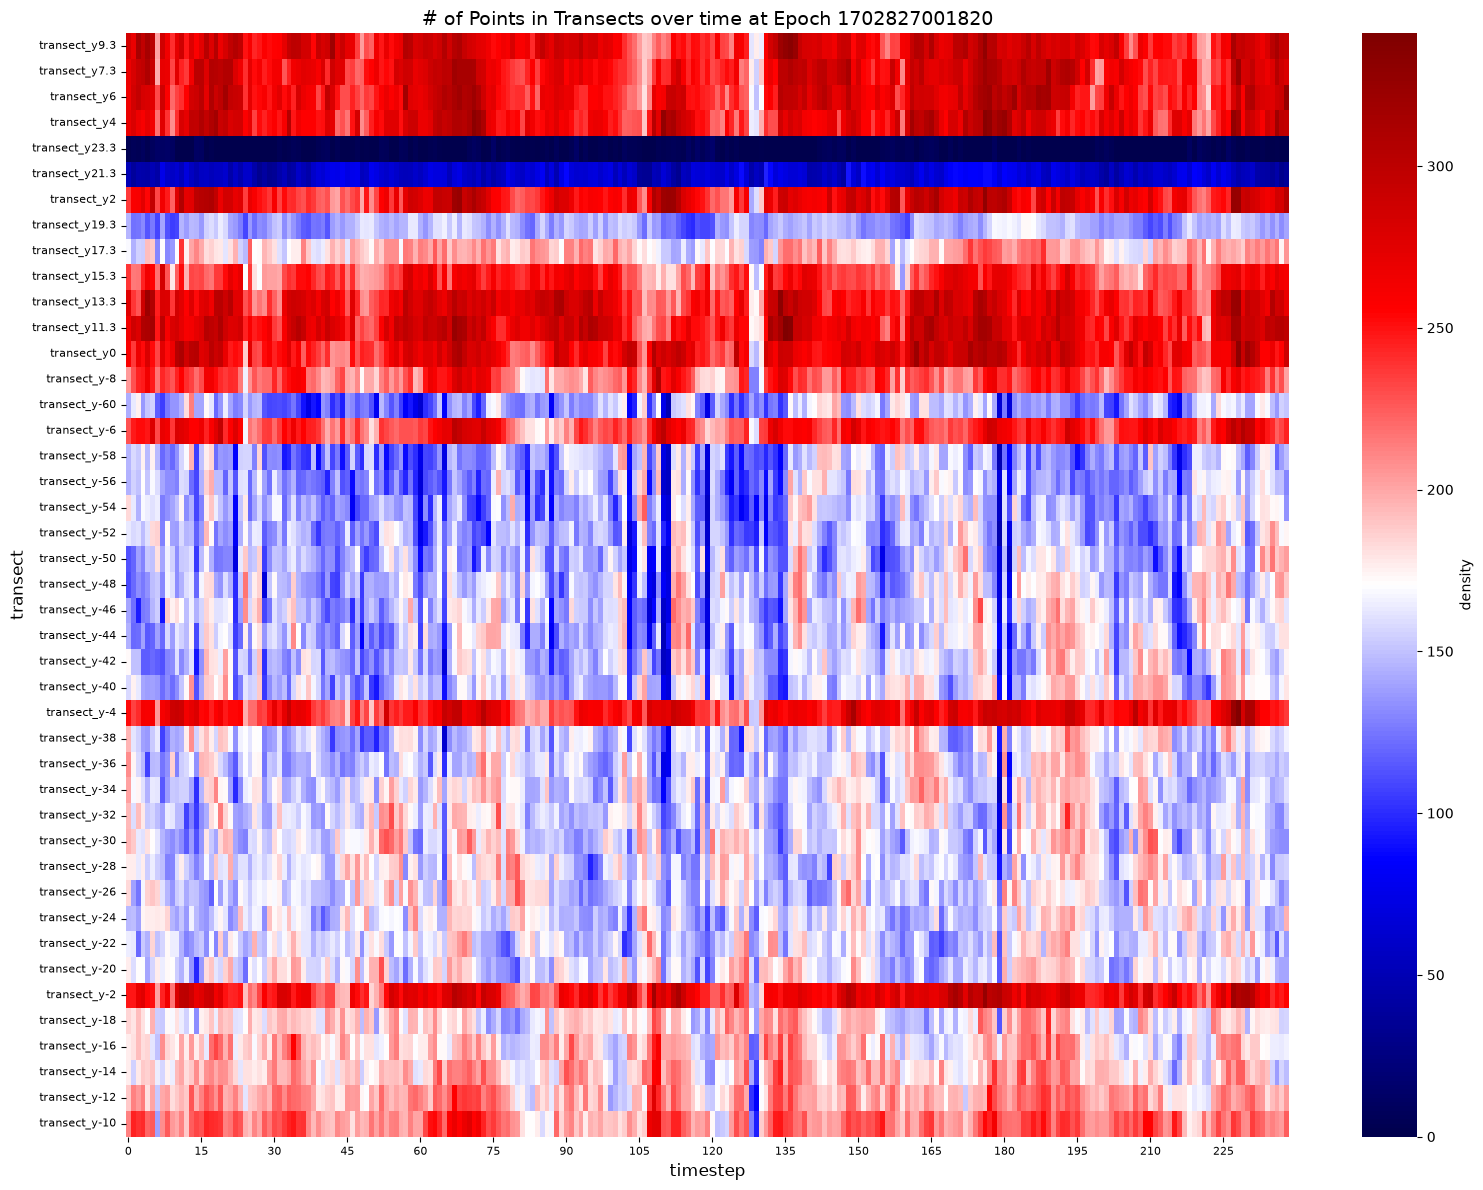

In [21]:
tran1702827001820=loadNprep(transect_1702827001820_path) # load
sorted_1820=sort_transects(tran1702827001820) #sort
sorted_1820=pd.concat(sorted_1820.values(), keys=sorted_1820.keys()) # dataframe

# point density 
pt_density_1820 = pd.DataFrame( {t_name: df.iloc[200:].count() for t_name, df in sorted_1820.groupby(level=0)} ) 
plot_density(pt_density_1820,figpath1820,'1702827001820')

plt.close('all')